# Weather Data Analysis - CDMX Airport (MMMX)

**Dataset:** Historical data from the Benito Juárez International Airport Weather Center, obtained through ethical scraping from an information provider for educational and scientific purposes.

**Notebook objectives:**
- Perform data cleaning and exploratory data analysis.
- Train a regression model to predict temperature.
- Train a logistic regression model to classify weather phenomena.
- Train a time series model for temporal prediction, specifically ARIMA.
- Train a more precise time series model using LSTM.

---

## 1. Import Libraries

In [41]:
# Main data analysis libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suppress warnings in outputs
import warnings
warnings.filterwarnings('ignore')

# Libraries for linear and logistic regression models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# Libraries for ARIMA time series models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Libraries for LSTM time series models
from tf_keras.models import Sequential
from tf_keras.layers import Dense, Dropout, InputLayer, LSTM
from tf_keras.callbacks import EarlyStopping

# Plot configuration
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Done")

Done


## 2. Load Data and Dataset Overview

In [81]:
# Load dataset
df = pd.read_csv('data/HistoricalWeather_MMMX_Dataset.csv')

print(f"Loaded Data: {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"Period: From {df['Date'].min()} to {df['Date'].max()}.")

Loaded Data: 98732 rows and 12 columns.
Period: From 2017-01-01 to 2025-10-31.


In [43]:
# Visualize first rows
df.head()

,DateTime,Date,Time24h,Time,Temperature(F),Dew Point(F),Humidity(%),Wind,Wind Speed(mph),Wind Gust(mph),Pressure(in),Condition
0,2017-01-10 00:46:00,2017-01-10,00:46,12:46 AM,48,37,66,E,5,0,23.18,Fair
1,2017-01-10 01:20:00,2017-01-10,01:20,1:20 AM,45,37,76,CALM,0,0,23.18,Fair
2,2017-01-10 01:44:00,2017-01-10,01:44,1:44 AM,46,37,71,ESE,3,0,23.18,Fair
3,2017-01-10 02:24:00,2017-01-10,02:24,2:24 AM,43,37,81,E,6,0,23.17,Fair
4,2017-01-10 02:42:00,2017-01-10,02:42,2:42 AM,41,36,81,ENE,6,0,23.17,Fair


In [44]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98732 entries, 0 to 98731
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DateTime         98732 non-null  object 
 1   Date             98732 non-null  object 
 2   Time24h          98732 non-null  object 
 3   Time             98732 non-null  object 
 4   Temperature(F)   98732 non-null  int64  
 5   Dew Point(F)     98732 non-null  int64  
 6   Humidity(%)      98732 non-null  int64  
 7   Wind             98720 non-null  object 
 8   Wind Speed(mph)  98732 non-null  int64  
 9   Wind Gust(mph)   98732 non-null  int64  
 10  Pressure(in)     98732 non-null  float64
 11  Condition        98732 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 9.0+ MB


In [45]:
# Basic statistics
df.describe()

,Temperature(F),Dew Point(F),Humidity(%),Wind Speed(mph),Wind Gust(mph),Pressure(in)
count,98732.000000,98732.000000,98732.000000,98732.000000,98732.000000,98732.000000
mean,64.676427,43.255206,51.150893,7.250182,0.611808,23.097145
std,8.569815,9.825933,21.709623,5.856017,4.003815,0.189648
min,0.000000,-9.000000,0.000000,0.000000,0.000000,0.000000
25%,59.000000,37.000000,34.000000,5.000000,0.000000,23.060000
50%,64.000000,45.000000,51.000000,6.000000,0.000000,23.100000
75%,72.000000,52.000000,68.000000,9.000000,0.000000,23.140000
max,104.000000,86.000000,100.000000,1039.000000,63.000000,23.330000


## 3. Data Cleaning

### 3.1 Null Values

In [46]:
# Check null values
print("Null values per column:")
print(df.isnull().sum())

Null values per column:
DateTime            0
Date                0
Time24h             0
Time                0
Temperature(F)      0
Dew Point(F)        0
Humidity(%)         0
Wind               12
Wind Speed(mph)     0
Wind Gust(mph)      0
Pressure(in)        0
Condition           0
dtype: int64


### 3.2 Outlier Detection and Removal

In [47]:
# Convert date column to datetime
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.set_index('DateTime')

# Working copy
df_clean = df.copy()

print(f"Rows before cleaning: {len(df_clean)}")

Rows before cleaning: 98732


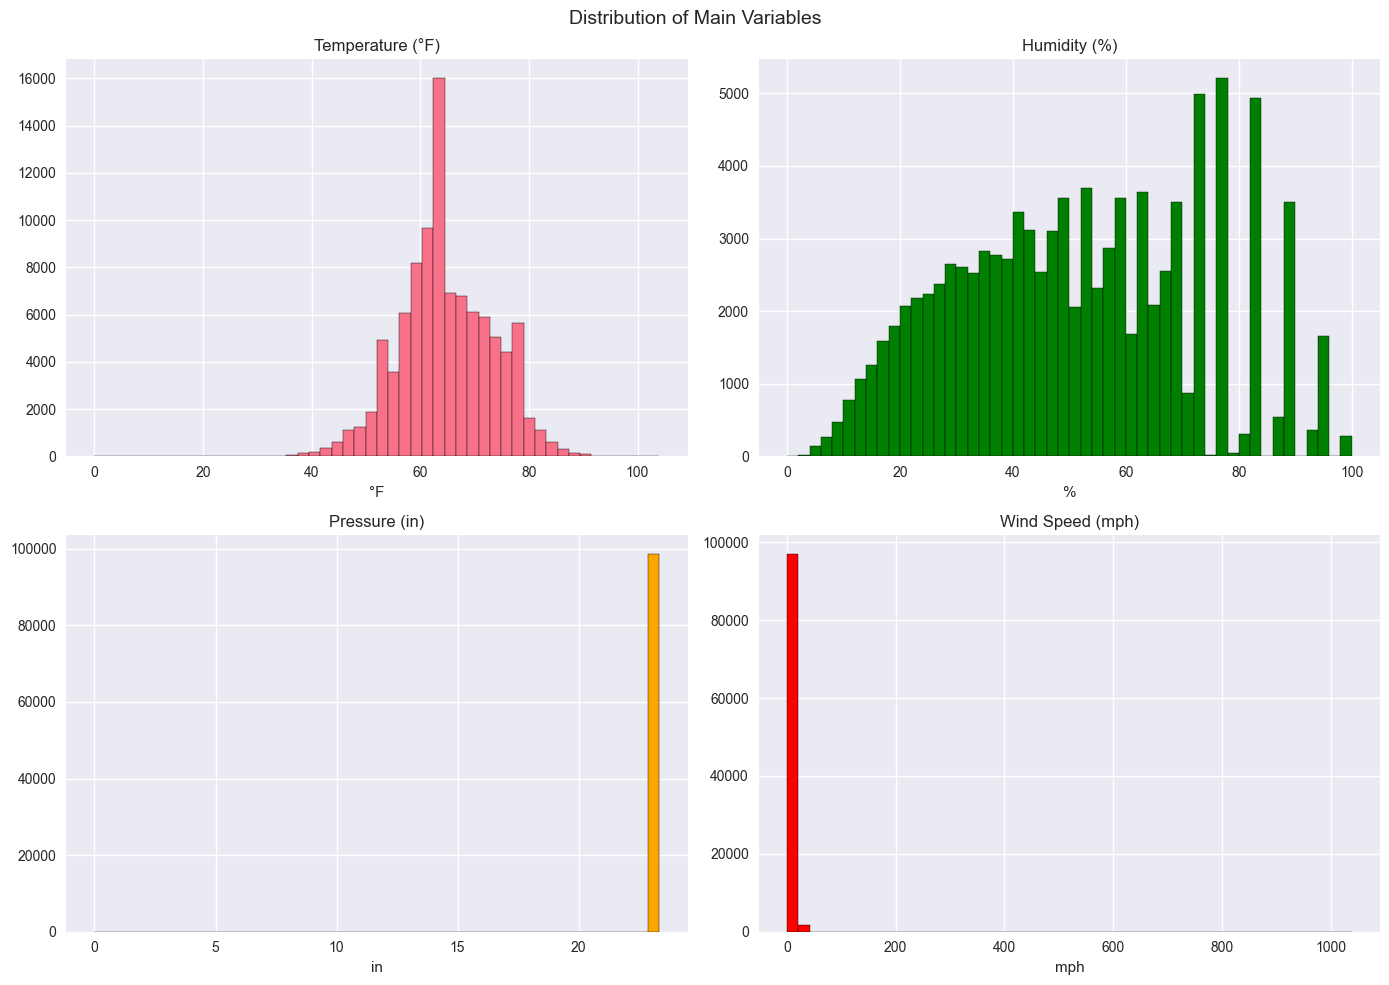

In [48]:
# Visualize distributions to detect outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Main Variables', fontsize=14)

axes[0,0].hist(df['Temperature(F)'], bins=50, edgecolor='black')
axes[0,0].set_title('Temperature (°F)')
axes[0,0].set_xlabel('°F')

axes[0,1].hist(df['Humidity(%)'], bins=50, edgecolor='black', color='green')
axes[0,1].set_title('Humidity (%)')
axes[0,1].set_xlabel('%')

axes[1,0].hist(df['Pressure(in)'], bins=50, edgecolor='black', color='orange')
axes[1,0].set_title('Pressure (in)')
axes[1,0].set_xlabel('in')

axes[1,1].hist(df['Wind Speed(mph)'], bins=50, edgecolor='black', color='red')
axes[1,1].set_title('Wind Speed (mph)')
axes[1,1].set_xlabel('mph')

plt.tight_layout()
plt.show()

In [49]:
# Remove extreme values outside reasonable ranges for CDMX
# Temperature: 20°F to 100°F
df_clean = df_clean[(df_clean['Temperature(F)'] >= 20) & (df_clean['Temperature(F)'] <= 100)]

# Atmospheric pressure: 22 to 24 in
df_clean = df_clean[(df_clean['Pressure(in)'] >= 22) & (df_clean['Pressure(in)'] <= 24)]

# Humidity: 0 to 100%
df_clean = df_clean[(df_clean['Humidity(%)'] >= 0) & (df_clean['Humidity(%)'] <= 100)]

# Wind speed: under 80 mph
df_clean = df_clean[df_clean['Wind Speed(mph)'] <= 80]

print(f"Rows after cleaning: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Rows after cleaning: 98718
Rows removed: 14


In [50]:
# Preview cleaned dataset
df_clean.head()

,Date,Time24h,Time,Temperature(F),Dew Point(F),Humidity(%),Wind,Wind Speed(mph),Wind Gust(mph),Pressure(in),Condition
DateTime,,,,,,,,,,,
2017-01-10 00:46:00,2017-01-10,00:46,12:46 AM,48,37,66,E,5,0,23.18,Fair
2017-01-10 01:20:00,2017-01-10,01:20,1:20 AM,45,37,76,CALM,0,0,23.18,Fair
2017-01-10 01:44:00,2017-01-10,01:44,1:44 AM,46,37,71,ESE,3,0,23.18,Fair
2017-01-10 02:24:00,2017-01-10,02:24,2:24 AM,43,37,81,E,6,0,23.17,Fair
2017-01-10 02:42:00,2017-01-10,02:42,2:42 AM,41,36,81,ENE,6,0,23.17,Fair


## 4. Exploratory Data Analysis

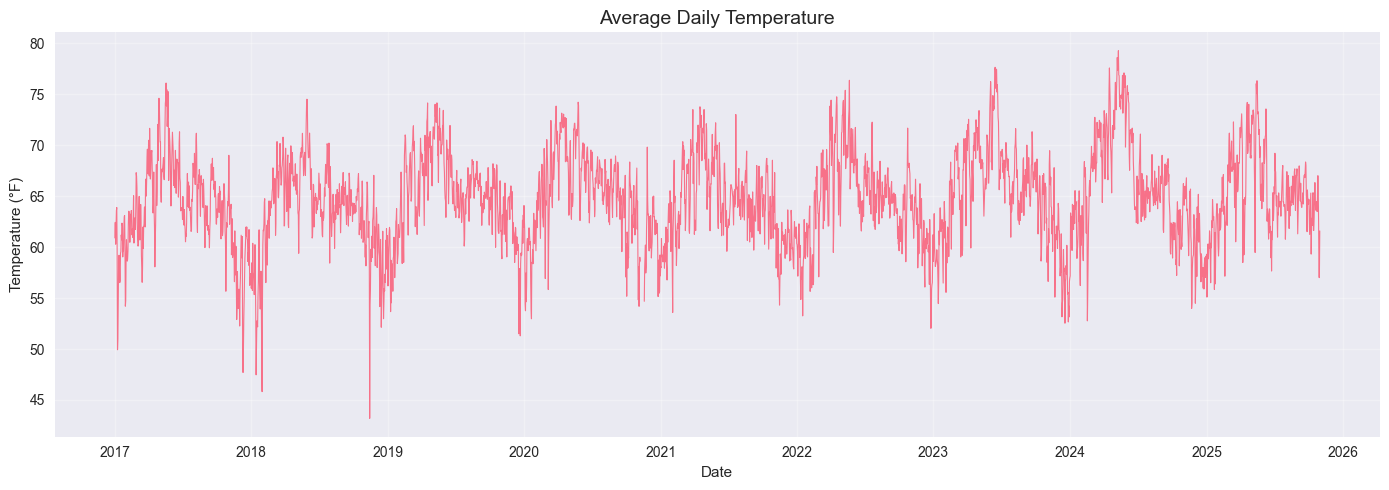

In [51]:
# Average daily temperature
daily_temp = df_clean['Temperature(F)'].resample('D').mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_temp.index, daily_temp.values, linewidth=0.8)
plt.title('Average Daily Temperature', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

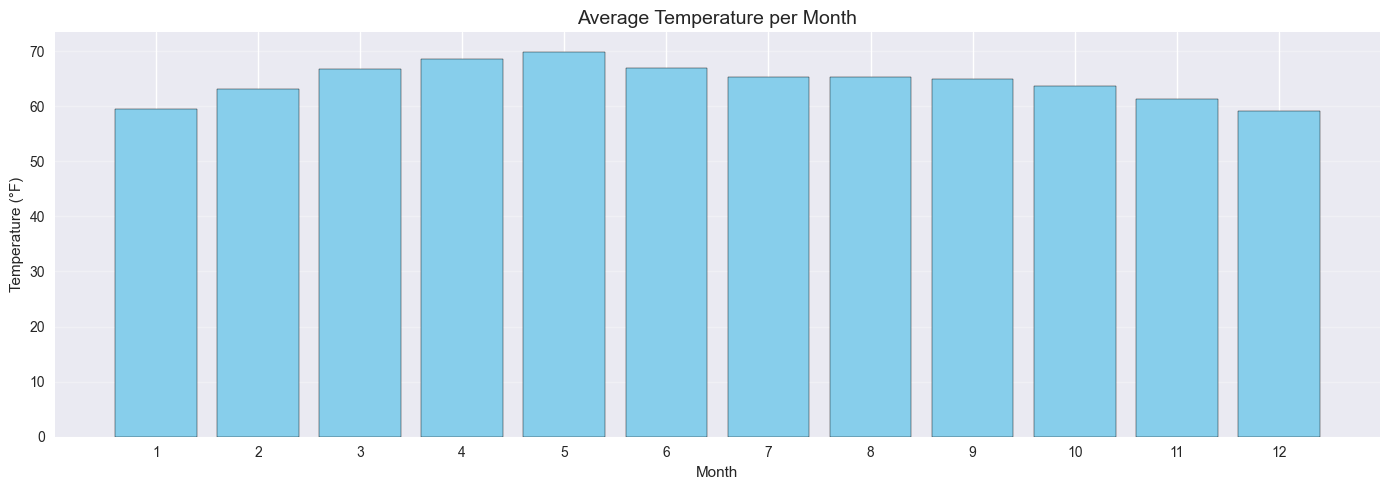

Hottest month: 5 (69.92726021110602°F)
Coldest month: 12 (59.059255304951286°F)


In [52]:
# Monthly temperature patterns
df_clean['Month'] = df_clean.index.month
monthly_avg = df_clean.groupby('Month')['Temperature(F)'].mean()

plt.figure(figsize=(14, 5))
plt.bar(monthly_avg.index, monthly_avg.values, color='skyblue', edgecolor='black')
plt.title('Average Temperature per Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Temperature (°F)')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Hottest month: {monthly_avg.idxmax()} ({monthly_avg.max()}°F)")
print(f"Coldest month: {monthly_avg.idxmin()} ({monthly_avg.min()}°F)")

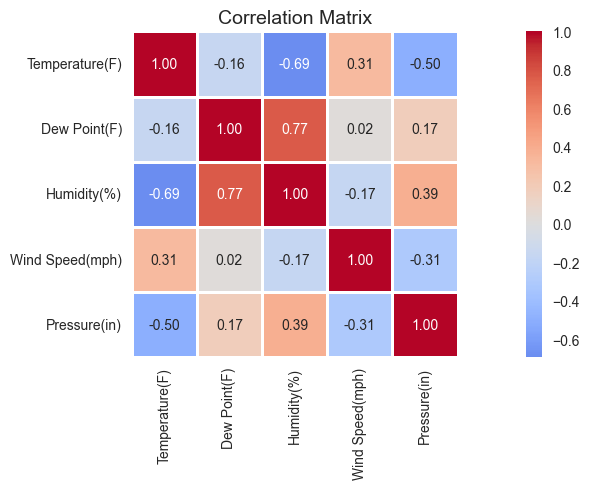

In [53]:
# Correlation matrix
numeric_cols = ['Temperature(F)', 'Dew Point(F)', 'Humidity(%)', 'Wind Speed(mph)', 'Pressure(in)']

corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(14, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Regression Model (Temperature Prediction)

### 5.1 Feature Engineering

In [54]:
# Create temporal features
df_clean['Hour'] = df_clean.index.hour
df_clean['DayOfWeek'] = df_clean.index.dayofweek
df_clean['DayOfYear'] = df_clean.index.dayofyear

print("Features created:")
print("- Hour: hour of day (0-23)")
print("- Month: month of year (1-12)")
print("- DayOfWeek: day of week (0=Monday, 6=Sunday)")
print("- DayOfYear: day of year (1-365)")

Features created:
- Hour: hour of day (0-23)
- Month: month of year (1-12)
- DayOfWeek: day of week (0=Monday, 6=Sunday)
- DayOfYear: day of year (1-365)


### 5.2 Train-Validation-Test Split (40-30-30 Rule)

In [55]:
# Select features and target
feature_cols = ['Dew Point(F)', 'Humidity(%)', 'Wind Speed(mph)', 'Pressure(in)', 'Month', 'Hour', 'DayOfWeek', 'DayOfYear']

df_model = df_clean[feature_cols + ['Temperature(F)']].dropna()

X = df_model[feature_cols]
y = df_model['Temperature(F)']

print(f"Total samples: {len(X)}")
print(f"Features: {len(feature_cols)}")

Total samples: 98718
Features: 8


In [56]:
# First split: 40% train, 60% remaining
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.6, random_state=42, shuffle=False)

# Second split: 30% validation, 30% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, shuffle=False)

print("Data split (40-30-30):")
print(f"Train: {len(X_train)} samples ({len(X_train)/len(X)*100}%)")
print(f"Validation: {len(X_val)} samples ({len(X_val)/len(X)*100}%)")
print(f"Test: {len(X_test)} samples ({len(X_test)/len(X)*100}%)")

Data split (40-30-30):
Train: 39487 samples (39.99979740270265%)
Validation: 29615 samples (29.999594805405295%)
Test: 29616 samples (30.000607791892058%)


In [57]:
# Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Data standardized with StandardScaler")

Data standardized with StandardScaler


### 5.3 Regression Model Training

In [58]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_val_pred_lr = lr_model.predict(X_val_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
lr_mae = mean_absolute_error(y_val, y_val_pred_lr)
lr_r2 = r2_score(y_val, y_val_pred_lr)

print("Linear Regression - Validation Set:")
print(f"R2: {lr_r2}")
print(f"RMSE: {lr_rmse}°F")
print(f"MAE: {lr_mae}°F")

Linear Regression - Validation Set:
R2: 0.825745312387916
RMSE: 3.411868990754536°F
MAE: 2.4662788327735377°F


In [59]:
# Model 2: Random Forest
rf_model = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_val_pred_rf = rf_model.predict(X_val_scaled)

rf_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
rf_mae = mean_absolute_error(y_val, y_val_pred_rf)
rf_r2 = r2_score(y_val, y_val_pred_rf)

print("Random Forest - Validation Set:")
print(f"R2: {rf_r2}")
print(f"RMSE: {rf_rmse}°F")
print(f"MAE: {rf_mae}°F")

Random Forest - Validation Set:
R2: 0.9915262201722718
RMSE: 0.75238252440136°F
MAE: 0.20493955553195697°F


### 5.4 Best Model Evaluation on Test Set

In [ ]:
# Compare models
results = pd.DataFrame({'Model': ['Linear Regression', 'Random Forest'],
                        'R2 (Val)': [lr_r2, rf_r2],
                        'RMSE (Val)': [lr_rmse, rf_rmse],
                        'MAE (Val)': [lr_mae, rf_mae]
                        })

print("Model comparison on Validation Set:")
print(results.to_string(index=False))

if rf_r2 > lr_r2:
    best_model = rf_model
    best_model_name = 'Random Forest'
else:
    best_model = lr_model
    best_model_name = 'Linear Regression'

print(f"Best model: {best_model_name}")

Model comparison on Validation Set:
            Model  R2 (Val)  RMSE (Val)  MAE (Val)
Linear Regression  0.825745    3.411869   2.466279
    Random Forest  0.991526    0.752383   0.204940
Best model: Random Forest


In [61]:
# Evaluate on Test Set
y_test_pred = best_model.predict(X_test_scaled)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"{best_model_name} - Test Set (final evaluation):")
print(f"R2: {test_r2}")
print(f"RMSE: {test_rmse}°F")
print(f"MAE: {test_mae}°F")
print(f"The model explains {test_r2*100}% of temperature variance.")

Random Forest - Test Set (final evaluation):
R2: 0.9867084236480059
RMSE: 1.0087406730544082°F
MAE: 0.3312454959421712°F
The model explains 98.67084236480059% of temperature variance.


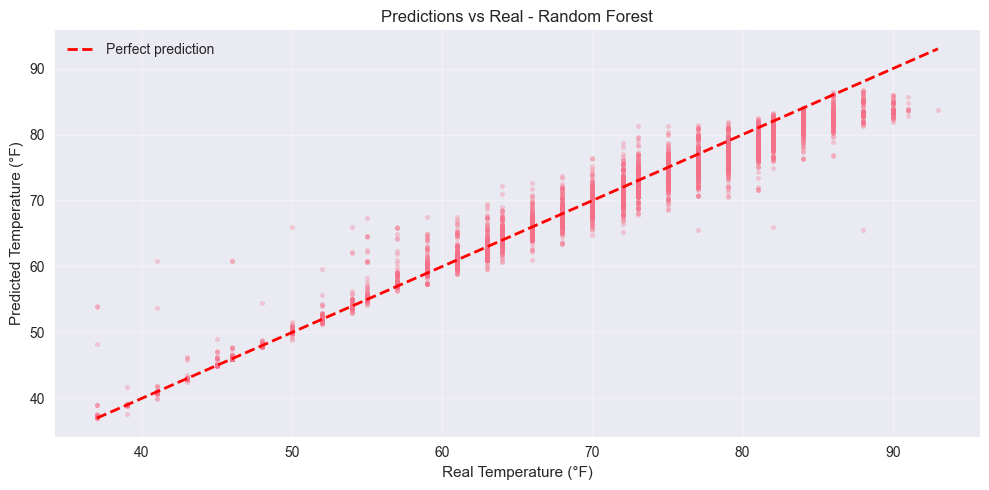

In [62]:
# Predictions vs real values
plt.figure(figsize=(10, 5))

plt.scatter(y_test, y_test_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Real Temperature (°F)')
plt.ylabel('Predicted Temperature (°F)')
plt.title(f'Predictions vs Real - {best_model_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 6. Classification - Identifying Hot Days (Logistic Regression)

Logistic Regression is used to classify whether a day was "hot" or not, based on historical data.

In [63]:
# Create target variable: hot day
threshold = 75  # °F
df_clean['Hot_Day'] = (df_clean['Temperature(F)'] > threshold).astype(int)

print("Days distribution:")
print(df_clean['Hot_Day'].value_counts())
print(f"Hot days: {(df_clean['Hot_Day'].sum() / len(df_clean) * 100)}%")

Days distribution:
Hot_Day
0    89217
1     9501
Name: count, dtype: int64
Hot days: 9.624384610709292%


In [64]:
# Classification features (temperature excluded to avoid leakage)
class_features = ['Dew Point(F)', 'Humidity(%)', 'Wind Speed(mph)', 'Pressure(in)', 'Month', 'Hour']

df_class = df_clean[class_features + ['Hot_Day']].dropna()

X_class = df_class[class_features]
y_class = df_class['Hot_Day']

print(f"Total samples for classification: {len(X_class)}")

Total samples for classification: 98718


In [65]:
# Train-test split (70-30)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.3, random_state=42, stratify=y_class)

print(f"Train: {len(X_train_c)} samples")
print(f"Test:  {len(X_test_c)} samples")

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

Train: 69102 samples
Test:  29616 samples


In [66]:
# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_c_scaled, y_train_c)

y_pred_c = log_model.predict(X_test_c_scaled)

accuracy = accuracy_score(y_test_c, y_pred_c)

print(f"Logistic Regression - Test Set:")
print(f"Accuracy: {accuracy} ({accuracy*100}%)")

Logistic Regression - Test Set:
Accuracy: 0.9680915721231766 (96.80915721231767%)


In [67]:
# Classification report
print("Classification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=['Not Hot', 'Hot']))

Classification Report:
              precision    recall  f1-score   support

     Not Hot       0.98      0.99      0.98     26766
         Hot       0.85      0.81      0.83      2850

    accuracy                           0.97     29616
   macro avg       0.92      0.90      0.91     29616
weighted avg       0.97      0.97      0.97     29616



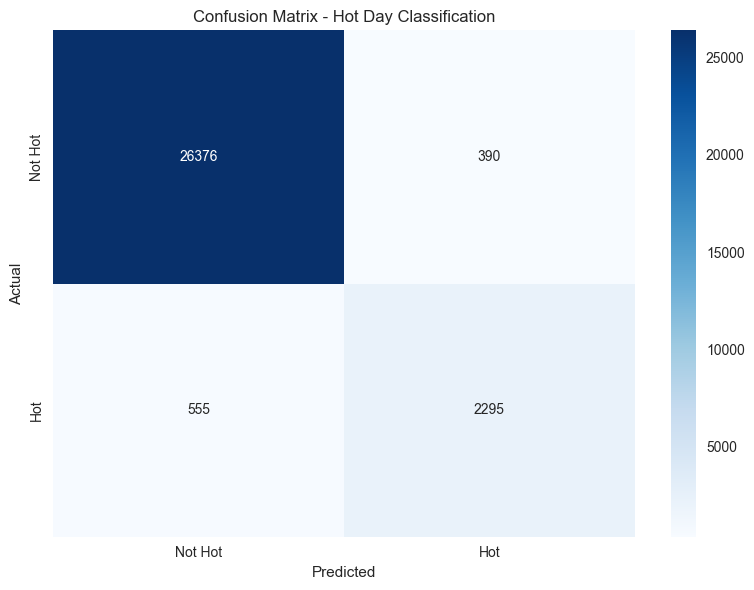

In [68]:
# Confusion matrix
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Hot', 'Hot'], yticklabels=['Not Hot', 'Hot'])
plt.title('Confusion Matrix - Hot Day Classification')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

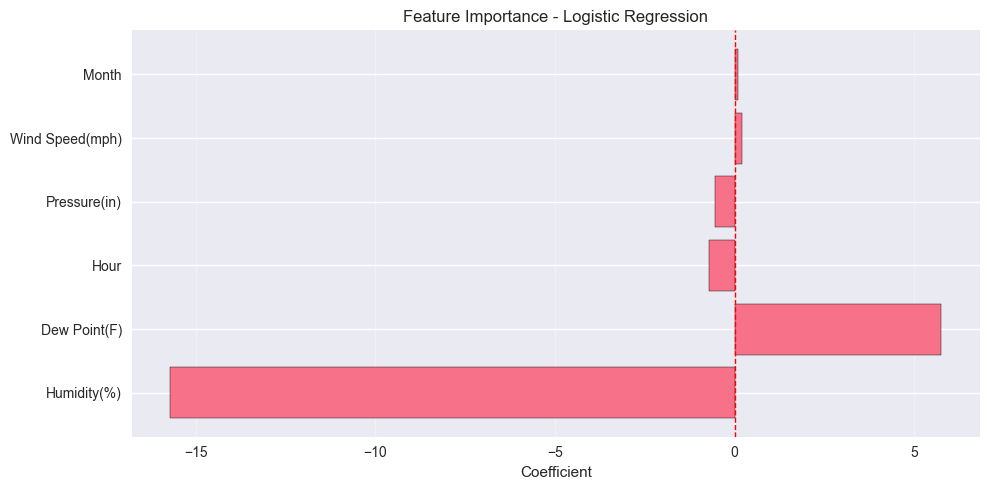

Interpretation:
- Positive coefficients: higher probability of hot day
- Negative coefficients: lower probability of hot day


In [69]:
# Feature importance (coefficients)
coef_df = pd.DataFrame({'Feature': class_features,
                        'Coefficient': log_model.coef_[0]
                        }).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], edgecolor='black')
plt.xlabel('Coefficient')
plt.title('Feature Importance - Logistic Regression')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Positive coefficients: higher probability of hot day")
print("- Negative coefficients: lower probability of hot day")

---

## 7. Time Series (ARIMA)

A simple ARIMA model is used to predict temperature based on the time series.

In [70]:
# Prepare daily data for time series
ts_data = df_clean['Temperature(F)'].resample('D').mean().dropna()

print(f"Time series data: {len(ts_data)} days")
print(f"Period: {ts_data.index[0].date()} to {ts_data.index[-1].date()}")

Time series data: 3216 days
Period: 2017-01-01 to 2025-10-31


In [71]:
# Chronological split: last 30 days for test
train_size = len(ts_data) - 30
ts_train = ts_data[:train_size]
ts_test = ts_data[train_size:]

print(f"Train: {len(ts_train)} days")
print(f"Test:  {len(ts_test)} days")

Train: 3186 days
Test:  30 days


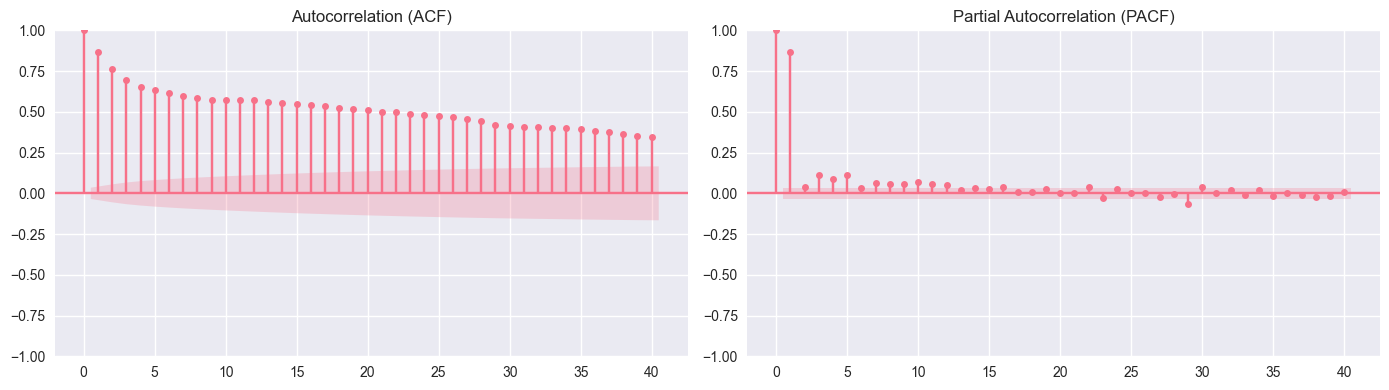

In [72]:
# ACF and PACF to determine model parameters
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(ts_train, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')

plot_pacf(ts_train, lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()

In [73]:
# Train ARIMA(1,1,1)
arima_model = ARIMA(ts_train, order=(1, 1, 1))
arima_fitted = arima_model.fit()

print("ARIMA(1,1,1) trained")
print("Summary:")
print(arima_fitted.summary())

ARIMA(1,1,1) trained
Summary:
                               SARIMAX Results                                
Dep. Variable:         Temperature(F)   No. Observations:                 3186
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -7032.354
Date:                Sun, 15 Mar 2026   AIC                          14070.709
Time:                        00:01:08   BIC                          14088.907
Sample:                             0   HQIC                         14077.235
                               - 3186                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6634      0.018     37.383      0.000       0.629       0.698
ma.L1         -0.9209      0.010    -93.203      0.000      -0.940      -0.902
sigma2         4.8446 

In [74]:
# Forecast
ts_predictions = arima_fitted.forecast(steps=len(ts_test))

ts_rmse = np.sqrt(mean_squared_error(ts_test, ts_predictions))
ts_mae = mean_absolute_error(ts_test, ts_predictions)

print(f"ARIMA - Test Set:")
print(f"RMSE: {ts_rmse}°F")
print(f"MAE: {ts_mae}°F")

ARIMA - Test Set:
RMSE: 3.0102447993367845°F
MAE: 2.1578942255801064°F


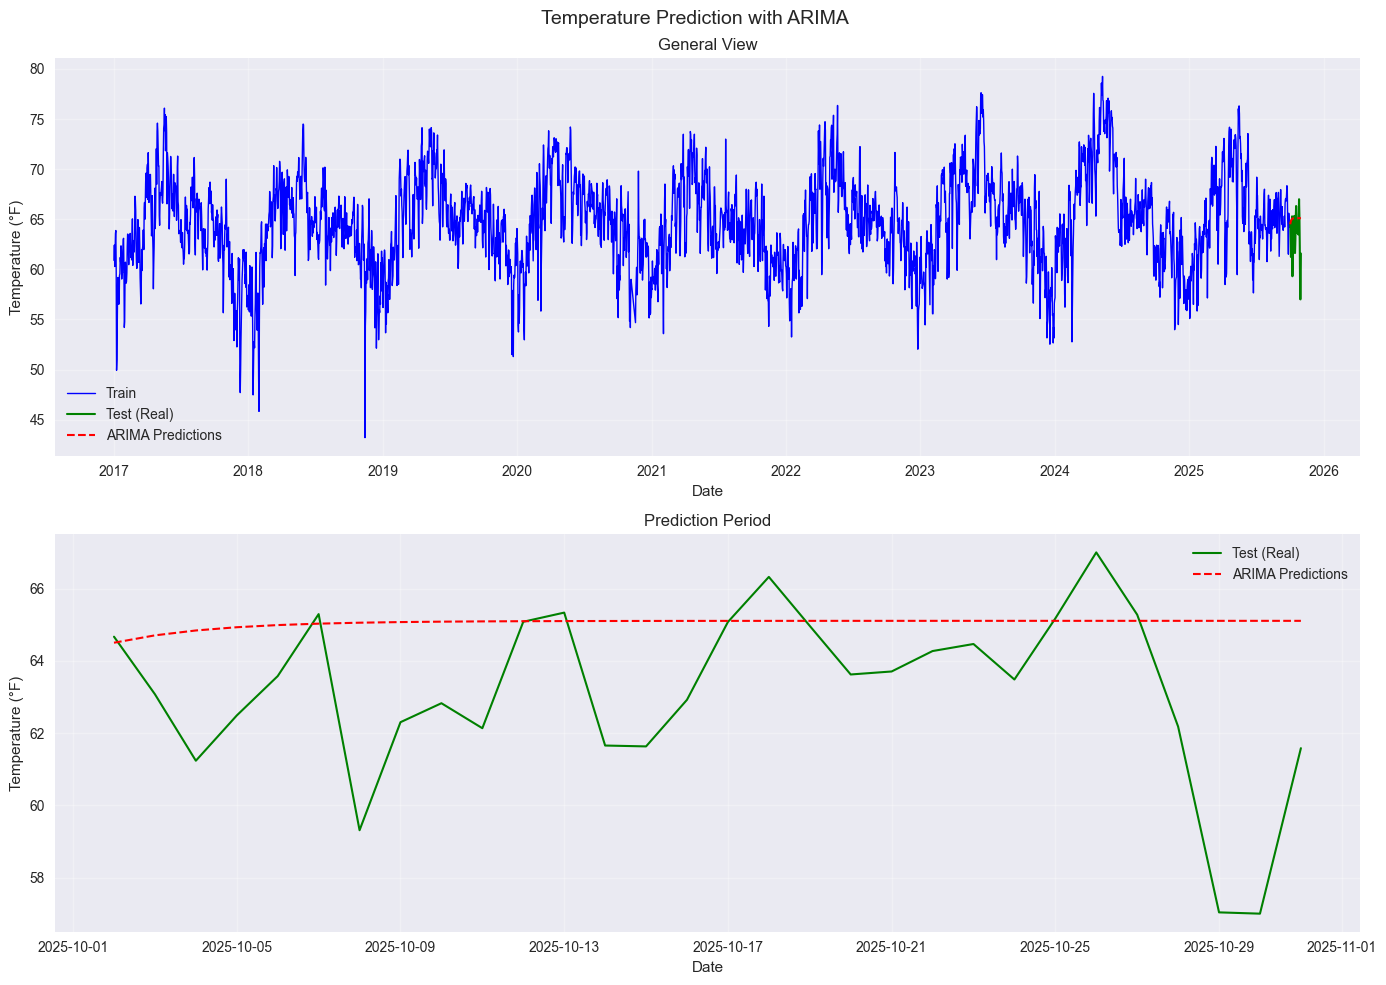

In [75]:
# Plot predictions
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(ts_train.index, ts_train.values, label='Train', color='blue', linewidth=1)
axes[0].plot(ts_test.index, ts_test.values, label='Test (Real)', color='green', linewidth=1.5)
axes[0].plot(ts_test.index, ts_predictions, label='ARIMA Predictions', color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('General View')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Temperature (°F)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ts_test.index, ts_test.values, label='Test (Real)', color='green', linewidth=1.5)
axes[1].plot(ts_test.index, ts_predictions, label='ARIMA Predictions', color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Prediction Period')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Temperature (°F)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Temperature Prediction with ARIMA', fontsize=14)
plt.tight_layout()
plt.show()

---

## 8. LSTM



In [76]:
# Hourly data resampled to fixed frequency
lstmData = df_clean['Temperature(F)'].resample('h').mean()
lstmData = lstmData.interpolate(method='time')

print(f"LSTM data: {len(lstmData)} hourly readings")
print(f"Period: {lstmData.index[0]} to {lstmData.index[-1]}")

LSTM data: 77424 hourly readings
Period: 2017-01-01 00:00:00 to 2025-10-31 23:00:00


In [ ]:
# Normalize to [0, 1]
lstmScaler = MinMaxScaler()
lstmScaled = lstmScaler.fit_transform(lstmData.values.reshape(-1, 1))

# Build sequences: 24h history -> predict next hour
LOOK_BACK = 24

def build_sequences(data, lookBack):
    X, y = [], []
    for i in range(lookBack, len(data)):
        X.append(data[i - lookBack:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_lstm, y_lstm = build_sequences(lstmScaled, LOOK_BACK)

# Chronological split 80/20
splitIdx = int(len(X_lstm) * 0.8)
X_lstm_train, X_lstm_test = X_lstm[:splitIdx], X_lstm[splitIdx:]
y_lstm_train, y_lstm_test = y_lstm[:splitIdx], y_lstm[splitIdx:]

# LSTM expects shape (samples, timesteps, features)
X_lstm_train = X_lstm_train.reshape(-1, LOOK_BACK, 1)
X_lstm_test  = X_lstm_test.reshape(-1, LOOK_BACK, 1)

print(f"Train: {X_lstm_train.shape}")
print(f"Test: {X_lstm_test.shape}")

Train: (61920, 24, 1) | Test: (15480, 24, 1)


In [78]:
lstmModel = Sequential([LSTM(64, return_sequences=True, input_shape=(LOOK_BACK, 1)),
                        Dropout(0.2),
                        LSTM(32),
                        Dropout(0.2),
                        Dense(1)
                        ])

lstmModel.compile(optimizer='adam', loss='mse')
lstmModel.summary()

earlyStopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lstmHistory = lstmModel.fit(X_lstm_train, y_lstm_train,
                            epochs=50,
                            batch_size=64,
                            validation_split=0.1,
                            callbacks=[earlyStopping],
                            verbose=1
                            )

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 24, 64)            16896     
                                                                 
 dropout_2 (Dropout)         (None, 24, 64)            0         
                                                                 
 lstm_3 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/50
871/8

484/484 [==============================] - 4s 6ms/step
LSTM - Test Set:
RMSE: 1.6656373173399899°F
MAE:  1.2559332931677833°F


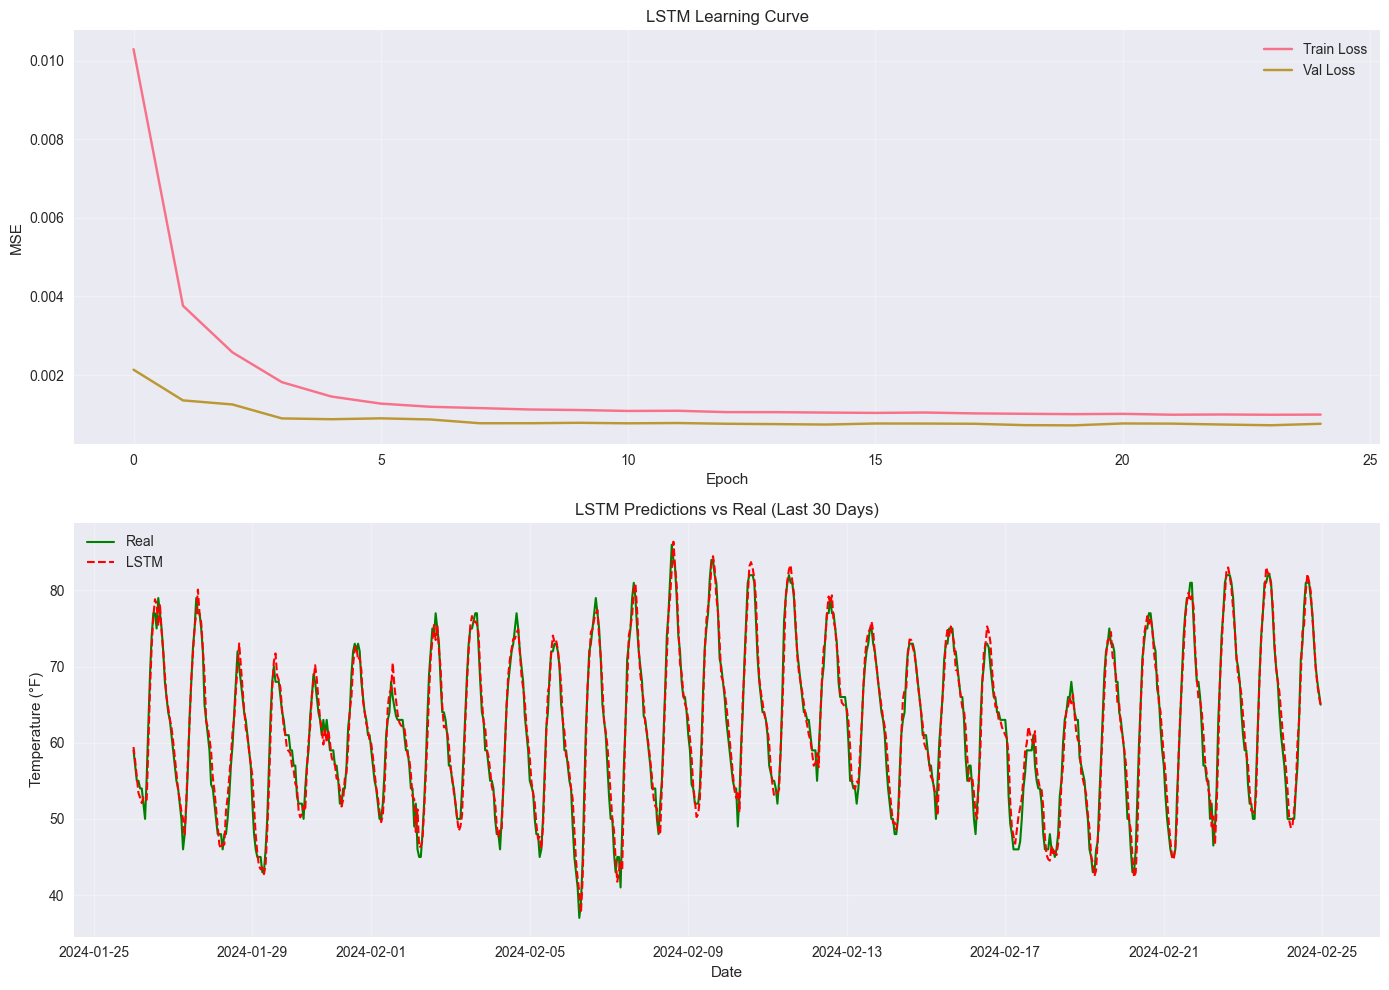

In [79]:
# Predictions and inverse transform
lstmPredScaled = lstmModel.predict(X_lstm_test)
lstmPred = lstmScaler.inverse_transform(lstmPredScaled)
lstmReal = lstmScaler.inverse_transform(y_lstm_test.reshape(-1, 1))
lstmTestIndex = lstmData.index[len(lstmData) - len(y_lstm_test):]

lstm_rmse = np.sqrt(mean_squared_error(lstmReal, lstmPred))
lstm_mae  = mean_absolute_error(lstmReal, lstmPred)

print(f"LSTM - Test Set:")
print(f"RMSE: {lstm_rmse}°F")
print(f"MAE:  {lstm_mae}°F")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Learning curve
axes[0].plot(lstmHistory.history['loss'], label='Train Loss')
axes[0].plot(lstmHistory.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM Learning Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predictions vs real (last 30 days)
axes[1].plot(lstmTestIndex[:720], lstmReal[:720], label='Real', color='green', linewidth=1.5)
axes[1].plot(lstmTestIndex[:720], lstmPred[:720], label='LSTM', color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('LSTM Predictions vs Real (Last 30 Days)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Temperature (°F)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Final Conclusions

In [80]:
print("PROJECT SUMMARY")

print("DATA:")
print(f"  Records: {len(df):,}")
print(f"  After cleaning: {len(df_clean)}")
print(f"  Outliers removed: {len(df) - len(df_clean)}")
print(f"  Period: 2017 - 2025")

print("MODELS:")

print("1. REGRESSION - Temperature prediction (sklearn)")
print(f"     Best model: {best_model_name}")
print(f"     R2 (Test): {test_r2}")
print(f"     MAE (Test): {test_mae}°F")
print(f"     Note: High R2 expected — Dew Point correlates strongly with temperature.")

print("2. CLASSIFICATION - Logistic Regression (sklearn)")
print(f"     Accuracy: {accuracy} ({accuracy*100}%)")
print(f"     Target: Hot days (temperature > {threshold}°F)")

print("3. TIME SERIES - ARIMA(1,1,1) (statsmodels)")
print(f"     RMSE (Test): {ts_rmse}°F")
print(f"     MAE (Test): {ts_mae}°F")
print(f"     Test set: {len(ts_test)} days reserved chronologically")
print(f"     Note: No seasonal component — reverts toward mean over longer horizons.")

print("4. TIME SERIES - LSTM (TensorFlow/Keras)")
print(f"     RMSE (Test): {lstm_rmse}°F")
print(f"     MAE (Test): {lstm_mae}°F")
print(f"     Resolution: Hourly (24h lookback)")
print(f"     Improvement vs ARIMA: {((ts_rmse - lstm_rmse) / ts_rmse * 100)}% lower RMSE")

print("CONCLUSION:")
print("  ARIMA captures short-term trends but not annual seasonality.")
print("  LSTM at hourly resolution reduces error significantly by capturing")
print("  daily cycles that ARIMA(1,1,1) cannot model. Natural next step:")
print("  SARIMA with seasonal period or density estimation models.")

PROJECT SUMMARY
DATA:
  Records: 98,732
  After cleaning: 98718
  Outliers removed: 14
  Period: 2017 - 2025
MODELS:
1. REGRESSION - Temperature prediction (sklearn)
     Best model: Random Forest
     R2 (Test): 0.9867084236480059
     MAE (Test): 0.3312454959421712°F
     Note: High R2 expected — Dew Point correlates strongly with temperature.
2. CLASSIFICATION - Logistic Regression (sklearn)
     Accuracy: 0.9680915721231766 (96.80915721231767%)
     Target: Hot days (temperature > 75°F)
3. TIME SERIES - ARIMA(1,1,1) (statsmodels)
     RMSE (Test): 3.0102447993367845°F
     MAE (Test): 2.1578942255801064°F
     Test set: 30 days reserved chronologically
     Note: No seasonal component — reverts toward mean over longer horizons.
4. TIME SERIES - LSTM (TensorFlow/Keras)
     RMSE (Test): 1.6656373173399899°F
     MAE (Test): 1.2559332931677833°F
     Resolution: Hourly (24h lookback)
     Improvement vs ARIMA: 44.66771215062103% lower RMSE
CONCLUSION:
  ARIMA captures short-term tren